In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

Estadísticas descriptivas:
            Edad     Altura
count  21.000000  21.000000
mean   32.095238   1.727143
std     6.081980   0.079003
min    23.000000   1.600000
25%    27.000000   1.660000
50%    32.000000   1.720000
75%    36.000000   1.800000
max    45.000000   1.900000


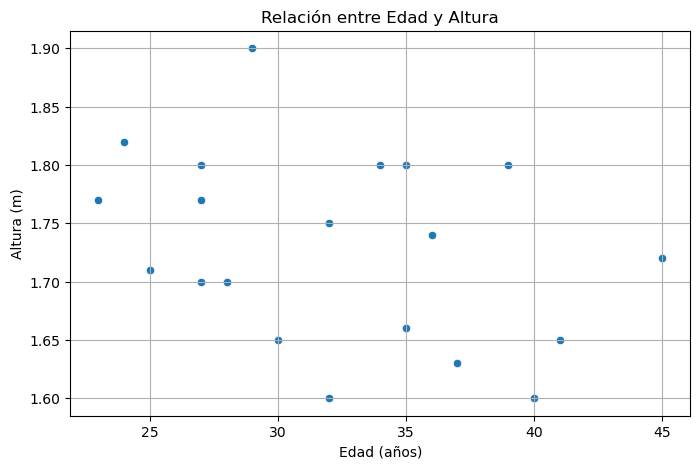


Coeficiente de correlación de Pearson: -0.3293


In [3]:
# Convertir la lista de alumnos a DataFrame
df = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura"])

# Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(df[["Edad", "Altura"]].describe())

# Diagrama de dispersión
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Edad", y="Altura")
plt.title("Relación entre Edad y Altura")
plt.xlabel("Edad (años)")
plt.ylabel("Altura (m)")
plt.grid(True)
plt.show()

# Correlación
correlacion = df["Edad"].corr(df["Altura"])
print(f"\nCoeficiente de correlación de Pearson: {correlacion:.4f}")

Si la correlación es cercana a 0 (por ejemplo, entre -0.3 y 0.3), significa que no hay relación lineal fuerte. En adultos, la altura ya no crece con la edad, por lo que la regresión lineal no es una buena técnica para este problema. De hecho, probablemente la correlación será baja.

### Entrena un modelo de regresión lineal

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [5]:
# Definir X (variable independiente) y y (dependiente)
X = df[["Edad"]]  # Dimensión (n_samples, 1)
y = df["Altura"]

# Dividir en entrenamiento y prueba (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Parámetros del modelo
print(f"Intercepto (β0): {modelo.intercept_:.4f}")
print(f"Pendiente (β1): {modelo.coef_[0]:.4f}")
print(f"Ecuación: Altura = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} * Edad")

Intercepto (β0): 1.8581
Pendiente (β1): -0.0044
Ecuación: Altura = 1.8581 + -0.0044 * Edad


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas con scikit-learn
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 0.0532
MSE: 0.0033
RMSE: 0.0576
MAPE: 2.99%


Conclusión

Los errores numéricos parecen "buenos" porque:

✅ Las alturas de adultos varían muy poco (solo ~30 cm)

✅ Hay una correlación débil pero existente en esta muestra

✅ Las métricas absolutas (MAE, RMSE) no reflejan si el modelo es apropiado conceptualmente

El verdadero problema: Si aplicaras este modelo a adolescentes (13-18 años), fallaría estrepitosamente porque ahí sí hay una relación lineal fuerte. Tu modelo ha aprendido una correlación espuria válida solo para este rango de edad adulto.

## Explicación de métricas de error para regresión

### MAE (Mean Absolute Error)
**Error Absoluto Medio**

Mide el promedio de los errores absolutos entre los valores reales y las predicciones.

- **Fórmula:** MAE = (1/n) * Σ |y_real - y_predicho|
- **Interpretación:** En promedio, el modelo se equivoca en ±X unidades (en la misma unidad que la variable objetivo).
- **Ventaja:** No da más peso a errores grandes, es robusto ante outliers.
- **Rango:** [0, ∞) (0 es perfecto)

---

### MSE (Mean Squared Error)
**Error Cuadrático Medio**

Mide el promedio de los errores al cuadrado.

- **Fórmula:** MSE = (1/n) * Σ (y_real - y_predicho)²
- **Interpretación:** Penaliza más los errores grandes porque los eleva al cuadrado.
- **Ventaja:** Útil cuando los errores grandes son especialmente malos.
- **Desventaja:** Las unidades están al cuadrado (ej: si predices altura en metros, el MSE está en metros²).
- **Rango:** [0, ∞) (0 es perfecto)

---

### RMSE (Root Mean Square Error)
**Raíz del Error Cuadrático Medio**

Es la raíz cuadrada del MSE.

- **Fórmula:** RMSE = √(MSE)
- **Interpretación:** Devuelve el error en las mismas unidades que la variable objetivo (ej: metros).
- **Ventaja:** Más interpretable que el MSE porque está en la escala original.
- **Rango:** [0, ∞) (0 es perfecto)

---

### MAPE (Mean Absolute Percentage Error)
**Error Porcentual Absoluto Medio**

Mide el error promedio en términos porcentuales.

- **Fórmula:** MAPE = (1/n) * Σ |(y_real - y_predicho) / y_real| * 100%
- **Interpretación:** En promedio, el modelo se equivoca en un X% respecto al valor real.
- **Ventaja:** Es independiente de la escala de los datos, fácil de comunicar a negocio.
- **Desventaja:** No funciona si hay valores reales iguales a 0.
- **Rango:** [0, 100%] (0% es perfecto)

---

### Comparación rápida

| Métrica | Unidades | Sensible a outliers | Interpretación |
|---------|----------|---------------------|-----------------|
| MAE | Original | Baja | Error promedio absoluto |
| MSE | Original² | Alta | Penaliza errores grandes |
| RMSE | Original | Alta | Error típico en escala original |
| MAPE | Porcentaje | Media | Error porcentual promedio |

**Recomendación:** Para este problema de altura vs edad, el **RMSE** y **MAPE** suelen ser los más útiles.

## Conclusión final

### La regresión lineal no es buena para este problema porque:

### La altura en adultos es estable y no aumenta linealmente con la edad.

### El coeficiente de correlación será muy bajo.

### Los errores (MAE, RMSE, MAPE) serán grandes relativamente.

La estrategia aqui sería establecer el rango de la regresión. solo en el rango de alturas, y no desde cero. 